TensorFlow version: 2.18.0
Keras Tuner version: 1.4.7
Training data shape: (60000, 28, 28, 1)
Test data shape:     (10000, 28, 28, 1)
Number of classes:   10
Reloading Tuner from kt_dir/cnn_mnist/tuner0.json

Best Hyperparameters found:
  - filters_1: 16
  - kernel_1: 3
  - filters_2: 64
  - kernel_2: 3
  - dense_units: 160
  - dropout: 0.0
  - learning_rate: 0.001
  - tuner/epochs: 10
  - tuner/initial_epoch: 4
  - tuner/bracket: 1
  - tuner/round: 1
  - tuner/trial_id: 0017
Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9046 - loss: 0.3182 - val_accuracy: 0.9832 - val_loss: 0.0572
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 915us/step - accuracy: 0.9851 - loss: 0.0493 - val_accuracy: 0.9855 - val_loss: 0.0492
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 990us/step - accuracy: 0.9906 - loss: 0.0310 - val_accuracy: 0.9844 - val_loss: 0.0540
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 909us/step - accuracy: 0.9920 - loss: 0.0237 - val_accuracy: 0.9862 - val_loss: 

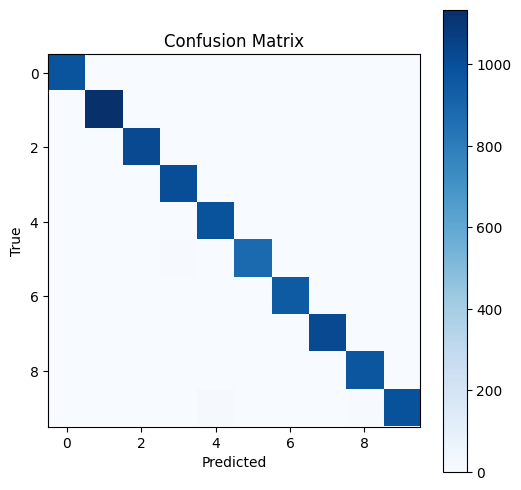

In [3]:
# ==============================================
# JUPYTER NOTEBOOK EXAMPLE:
# CNN Hyperparameter Tuning with Keras Tuner
# ==============================================

# 1. Imports
import tensorflow as tf
import keras_tuner as kt
import numpy as np
import matplotlib.pyplot as plt

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist
from sklearn.metrics import classification_report, confusion_matrix

# For cleaner output
import warnings
warnings.filterwarnings("ignore")
print("TensorFlow version:", tf.__version__)
print("Keras Tuner version:", kt.__version__)

# ==============================================
# 2. Load & Preprocess the MNIST Dataset
# ==============================================
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# MNIST images are 28x28, with pixel values in [0,255].
# We need to normalize them to [0,1] (float32) and expand dims to match (batch, height, width, channels).
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0
x_train = np.expand_dims(x_train, axis=-1)  # shape: (60000, 28, 28, 1)
x_test  = np.expand_dims(x_test, axis=-1)   # shape: (10000, 28, 28, 1)
print("Training data shape:", x_train.shape)
print("Test data shape:    ", x_test.shape)
print("Number of classes:  ", len(np.unique(y_train)))

# ==============================================
# 3. Define a HyperModel (CNN) for Keras Tuner
# ==============================================
def build_model(hp):
    """
    build_model(hp) defines a CNN architecture with hyperparameters
    for the number of filters, kernel size, dense units, dropout rate, and learning rate.
    """

    model = keras.Sequential()

    # Convolutional layer #1
    hp_filters_1 = hp.Int('filters_1', min_value=16, max_value=64, step=16)
    hp_kernel_1  = hp.Choice('kernel_1', values=[3, 5])
    model.add(layers.Conv2D(
        filters=hp_filters_1,
        kernel_size=hp_kernel_1,
        activation='relu',
        input_shape=(28, 28, 1))
    )
    model.add(layers.MaxPooling2D(pool_size=2))

    # Convolutional layer #2
    hp_filters_2 = hp.Int('filters_2', min_value=16, max_value=64, step=16)
    hp_kernel_2  = hp.Choice('kernel_2', values=[3, 5])
    model.add(layers.Conv2D(filters=hp_filters_2, kernel_size=hp_kernel_2, activation='relu'))
    model.add(layers.MaxPooling2D(pool_size=2))

    # Flatten + Dense
    model.add(layers.Flatten())

    # Hyperparameter for fully connected layer size
    hp_units = hp.Int('dense_units', min_value=32, max_value=256, step=32)
    model.add(layers.Dense(units=hp_units, activation='relu'))

    # Hyperparameter for dropout
    hp_dropout = hp.Float('dropout', min_value=0.0, max_value=0.5, default=0.2, step=0.1)
    model.add(layers.Dropout(hp_dropout))

    # Output layer (10 classes for MNIST)
    model.add(layers.Dense(10, activation='softmax'))

    # Compile
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-3, 3e-3, 1e-4])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=hp_learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# ==============================================
# 4. Initialize Keras Tuner (RandomSearch / Hyperband)
# ==============================================
# We'll use Hyperband for a more efficient search. 
# Alternatively, you can use RandomSearch or BayesianOptimization.

tuner = kt.Hyperband(
    build_model,
    objective='val_accuracy',
    max_epochs=30,           # max epochs for each model
    factor=3,                # Hyperband reduction factor
    directory='kt_dir',      # Directory to store logs
    project_name='cnn_mnist' # Project name for logs
)

# ==============================================
# 5. Define Callback for Early Stopping
# ==============================================
stop_early = keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)

# ==============================================
# 6. Perform the Hyperparameter Search
# ==============================================
tuner.search(
    x_train,
    y_train,
    epochs=10,
    validation_split=0.2,
    callbacks=[stop_early],
    verbose=1
)

# ==============================================
# 7. Retrieve the Best Model & Hyperparameters
# ==============================================
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print("\nBest Hyperparameters found:")
for param_name, param_value in best_hps.values.items():
    print(f"  - {param_name}: {param_value}")

best_model = tuner.hypermodel.build(best_hps)

# ==============================================
# 8. Train the Best Model (Optional Fine-Tuning)
# ==============================================
history = best_model.fit(
    x_train, y_train,
    epochs=20,             # Could train longer now that best params are known
    validation_split=0.2,
    verbose=1
)

# ==============================================
# 9. Evaluate on the Test Set
# ==============================================
test_loss, test_acc = best_model.evaluate(x_test, y_test, verbose=0)
print(f"\nTest Accuracy with Best Model: {test_acc:.4f}")

# Predictions for classification report
y_pred_probs = best_model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)
print("\nClassification Report (Test):")
print(classification_report(y_test, y_pred))

# (Optional) Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,6))
plt.imshow(cm, cmap='Blues')
plt.title("Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()